# Дерево-регрессор
Дерево-регрессор работает так же, как классификатор, но вместо классов предсказывает числовые значения.
- В каждом узле дерево ищет признак и порог, которые лучше всего разделяют данные:
- Вместо энтропии (для классификации) используются метрики ошибки. Например, MSE
- Предсказание = среднее значение в листе

# Используемые библиотеки

In [684]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import re
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Описание и демонстрация датасета

In [685]:
df = pd.read_csv('./data/laptopData.csv')

# таргет
y = df['Price']

# признаки (все столбцы кроме price)
X = df.drop(columns=['Price'])

In [686]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   str    
 2   TypeName          1273 non-null   str    
 3   Inches            1273 non-null   str    
 4   ScreenResolution  1273 non-null   str    
 5   Cpu               1273 non-null   str    
 6   Ram               1273 non-null   str    
 7   Memory            1273 non-null   str    
 8   Gpu               1273 non-null   str    
 9   OpSys             1273 non-null   str    
 10  Weight            1273 non-null   str    
dtypes: float64(1), str(10)
memory usage: 112.1 KB


In [687]:
X.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg


Разобьем выборку на обучение и тест с помощью `train_test_split`

In [688]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=0.3)

X_train.shape, X_test.shape

((912, 11), (391, 11))

# Препроцессинг датасета

## Обработка NaN

Посмотрим еще раз на X


In [689]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   str    
 2   TypeName          1273 non-null   str    
 3   Inches            1273 non-null   str    
 4   ScreenResolution  1273 non-null   str    
 5   Cpu               1273 non-null   str    
 6   Ram               1273 non-null   str    
 7   Memory            1273 non-null   str    
 8   Gpu               1273 non-null   str    
 9   OpSys             1273 non-null   str    
 10  Weight            1273 non-null   str    
dtypes: float64(1), str(10)
memory usage: 112.1 KB


Видим, что по всем признакам пропущено одинаковое количество значений.

Посмотрим на все записи, в которых пропущен хотя бы один признак

In [690]:
# Вывести все строки, где есть хотя бы один NaN
rows_with_nan = df[df.isna().any(axis=1)]

# Посмотреть результат
rows_with_nan

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


По факту, можно сказать, что этих записей и нет вовсе. Поэтому удалим их, чтобы они не мешались

In [691]:
# Train
train = pd.concat([X_train, y_train], axis=1)
train = train.dropna()

X_train = train.drop(columns=y_train.name)
y_train = train[y_train.name]

# Test
test = pd.concat([X_test, y_test], axis=1)
test = test.dropna()

X_test = test.drop(columns=y_test.name)
y_test = test[y_test.name]

Проверяем

In [692]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 892 entries, 428 to 1289
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        892 non-null    float64
 1   Company           892 non-null    str    
 2   TypeName          892 non-null    str    
 3   Inches            892 non-null    str    
 4   ScreenResolution  892 non-null    str    
 5   Cpu               892 non-null    str    
 6   Ram               892 non-null    str    
 7   Memory            892 non-null    str    
 8   Gpu               892 non-null    str    
 9   OpSys             892 non-null    str    
 10  Weight            892 non-null    str    
dtypes: float64(1), str(10)
memory usage: 83.6 KB


In [693]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 381 entries, 831 to 335
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        381 non-null    float64
 1   Company           381 non-null    str    
 2   TypeName          381 non-null    str    
 3   Inches            381 non-null    str    
 4   ScreenResolution  381 non-null    str    
 5   Cpu               381 non-null    str    
 6   Ram               381 non-null    str    
 7   Memory            381 non-null    str    
 8   Gpu               381 non-null    str    
 9   OpSys             381 non-null    str    
 10  Weight            381 non-null    str    
dtypes: float64(1), str(10)
memory usage: 35.7 KB


## Обработка категориальных признаков

### Unnamed

Этот признак фиктивный, поэтому его можем просто удалить

In [694]:
X_train = X_train.drop(columns=['Unnamed: 0'])
X_test = X_test.drop(columns=['Unnamed: 0'])

### `Company`

In [695]:
X_train['Company'].value_counts()

Company
Lenovo       204
Dell         198
HP           183
Asus         107
Acer          76
MSI           43
Toshiba       30
Apple         15
Samsung        7
Mediacom       6
Microsoft      5
Xiaomi         4
Razer          4
LG             3
Huawei         2
Google         2
Chuwi          1
Vero           1
Fujitsu        1
Name: count, dtype: int64

Уникальных значений не так много, поэтому можем оставить как есть



### `TypeName`

In [696]:
X_train['TypeName'].value_counts(dropna=False)

TypeName
Notebook              483
Gaming                148
Ultrabook             138
2 in 1 Convertible     86
Workstation            21
Netbook                16
Name: count, dtype: int64

Уникальных значений не так много, поэтому можем оставить как есть


### `ScreenResolution`

In [697]:
X_train['ScreenResolution'].value_counts(dropna=False)

ScreenResolution
Full HD 1920x1080                                336
1366x768                                         195
IPS Panel Full HD 1920x1080                      160
IPS Panel Full HD / Touchscreen 1920x1080         40
Full HD / Touchscreen 1920x1080                   33
1600x900                                          16
Touchscreen 1366x768                              13
Quad HD+ / Touchscreen 3200x1800                  10
IPS Panel 4K Ultra HD 3840x2160                    8
IPS Panel 4K Ultra HD / Touchscreen 3840x2160      8
IPS Panel Retina Display 2560x1600                 6
4K Ultra HD / Touchscreen 3840x2160                6
IPS Panel Quad HD+ / Touchscreen 3200x1800         5
Touchscreen 2256x1504                              5
IPS Panel 1366x768                                 4
Touchscreen 2560x1440                              4
IPS Panel Retina Display 2304x1440                 4
4K Ultra HD 3840x2160                              4
IPS Panel 2560x1440          

Разделим признак ScreenResolution на три признака:

*   ScreenType - тип экрана (Full HD, IPD Panel Quad HD+, ...)
*   ScreenWidth - ширина экрана
*   ScreenHeight - высота экрана


In [698]:
def parse_screen(resolution):
    # ищем числа перед и после 'x'
    match = re.search(r'(\d+)x(\d+)', resolution)
    if match:
        width = int(match.group(1))
        height = int(match.group(2))
    else:
        width = None
        height = None

    # убираем цифры с x, остальное — тип экрана
    screen_type = re.sub(r'\d+x\d+', '', resolution).strip()

    return pd.Series([screen_type, width, height])

In [699]:
# Train
X_train[['ScreenType', 'ScreenWidth', 'ScreenHeight']] = X_train['ScreenResolution'].apply(parse_screen)
X_train = X_train.drop(columns='ScreenResolution')
X_train['ScreenType'] = X_train['ScreenType'].replace('', 'Nope')

# Test
X_test[['ScreenType', 'ScreenWidth', 'ScreenHeight']] = X_test['ScreenResolution'].apply(parse_screen)
X_test = X_test.drop(columns='ScreenResolution')
X_test['ScreenType'] = X_test['ScreenType'].replace('', 'Nope')

In [700]:
X_train['ScreenType'].value_counts(dropna=False)

ScreenType
Full HD                                336
Nope                                   216
IPS Panel Full HD                      163
IPS Panel Full HD / Touchscreen         40
Full HD / Touchscreen                   33
Touchscreen                             24
IPS Panel Retina Display                14
Quad HD+ / Touchscreen                  10
IPS Panel 4K Ultra HD                    8
IPS Panel 4K Ultra HD / Touchscreen      8
IPS Panel Touchscreen                    8
IPS Panel                                7
4K Ultra HD / Touchscreen                6
IPS Panel Quad HD+ / Touchscreen         5
4K Ultra HD                              4
IPS Panel Quad HD+                       3
IPS Panel Touchscreen / 4K Ultra HD      2
Quad HD+                                 2
Touchscreen / Quad HD+                   1
Touchscreen / 4K Ultra HD                1
Touchscreen / Full HD                    1
Name: count, dtype: int64

Выделим дополнительные категории

*   HasTouchscreen
*   Has4K
*   HasFullHD
*   HasIPSPanel
*   HasQuad

In [701]:
# Train
X_train['ScreenTypeHasTouchscreen'] = X_train['ScreenType'].str.contains('Touchscreen', case=False, na=False).astype(int)
X_train['ScreenTypeHas4K']          = X_train['ScreenType'].str.contains('4K', case=False, na=False).astype(int)
X_train['ScreenTypeHasFullHD']      = X_train['ScreenType'].str.contains('Full HD', case=False, na=False).astype(int)
X_train['ScreenTypeHasIPSPanel']    = X_train['ScreenType'].str.contains('IPS Panel', case=False, na=False).astype(int)
X_train['ScreenTypeHasQuad']        = X_train['ScreenType'].str.contains('Quad', case=False, na=False).astype(int)

# Test
X_test['ScreenTypeHasTouchscreen'] = X_test['ScreenType'].str.contains('Touchscreen', case=False, na=False).astype(int)
X_test['ScreenTypeHas4K']          = X_test['ScreenType'].str.contains('4K', case=False, na=False).astype(int)
X_test['ScreenTypeHasFullHD']      = X_test['ScreenType'].str.contains('Full HD', case=False, na=False).astype(int)
X_test['ScreenTypeHasIPSPanel']    = X_test['ScreenType'].str.contains('IPS Panel', case=False, na=False).astype(int)
X_test['ScreenTypeHasQuad']        = X_test['ScreenType'].str.contains('Quad', case=False, na=False).astype(int)

In [702]:
# Train
X_train = X_train.drop(columns='ScreenType')

# Test
X_test = X_test.drop(columns='ScreenType')

### `Cpu`

In [703]:
X_train['Cpu'].value_counts(dropna=False)

Cpu
Intel Core i5 7200U 2.5GHz              119
Intel Core i7 7700HQ 2.8GHz             106
Intel Core i7 7500U 2.7GHz               88
Intel Core i7 8550U 1.8GHz               58
Intel Core i5 8250U 1.6GHz               46
                                       ... 
AMD A12-Series 9720P 3.6GHz               1
AMD A9-Series 9410 2.9GHz                 1
Intel Pentium Dual Core 4405U 2.1GHz      1
Intel Core i5 6260U 1.8GHz                1
Intel Core i7 6500U 2.50GHz               1
Name: count, Length: 106, dtype: int64

Разделим этот признак на два:


*   CpuModel
*   CpuFrequency



In [704]:
def parse_cpu(cpu_str):
    if pd.isna(cpu_str) or cpu_str == 'Nope':
        return pd.Series([None, None])

    # CPU Model — первые три слова
    words = cpu_str.split()
    cpu_model = ' '.join(words[:1])

    # CPU Frequency — число перед GHz
    freq_match = re.search(r'(\d+\.?\d*)GHz', cpu_str)
    cpu_freq = float(freq_match.group(1)) if freq_match else None

    return pd.Series([cpu_model, cpu_freq])

In [705]:
# Train
X_train[['CpuModel', 'CpuFrequency']] = X_train['Cpu'].apply(parse_cpu)

# Test
X_test[['CpuModel', 'CpuFrequency']] = X_test['Cpu'].apply(parse_cpu)


In [706]:
X_train['CpuModel'].value_counts(dropna=False)

CpuModel
Intel      850
AMD         41
Samsung      1
Name: count, dtype: int64

In [707]:
X_train['CpuFrequency'].value_counts(dropna=False)

CpuFrequency
2.50    192
2.80    121
2.70    113
1.60     90
1.80     62
2.30     58
2.00     58
2.60     49
1.10     36
2.40     35
2.90     16
3.00     12
1.20     11
2.20      8
1.44      7
1.50      6
1.30      4
3.10      3
0.90      3
1.90      2
2.10      2
1.00      1
1.92      1
3.20      1
3.60      1
Name: count, dtype: int64

In [708]:
# Train
X_train = X_train.drop(columns='Cpu')

# Test
X_test = X_test.drop(columns='Cpu')

### `Ram`

In [709]:
X_train['Ram'].value_counts(dropna=False)

Ram
8GB     419
4GB     254
16GB    135
6GB      30
2GB      19
12GB     16
32GB     12
64GB      3
24GB      3
1GB       1
Name: count, dtype: int64

Уберем постфикс GB, сделав признак числовым

In [710]:
# Train
X_train['Ram'] = X_train['Ram'].str.replace('GB', '', regex=False).astype(int)

#Test
X_test['Ram'] = X_test['Ram'].str.replace('GB', '', regex=False).astype(int)


X_train['Ram'].value_counts()

Ram
8     419
4     254
16    135
6      30
2      19
12     16
32     12
64      3
24      3
1       1
Name: count, dtype: int64

### `Memory`

In [711]:
X_train['Memory'].value_counts()

Memory
256GB SSD                    272
1TB HDD                      159
500GB HDD                     96
512GB SSD                     88
128GB SSD +  1TB HDD          65
256GB SSD +  1TB HDD          56
128GB SSD                     48
32GB Flash Storage            24
1TB SSD                       10
512GB SSD +  1TB HDD           9
2TB HDD                        9
64GB Flash Storage             9
16GB Flash Storage             6
128GB Flash Storage            4
1.0TB Hybrid                   4
32GB SSD                       4
256GB SSD +  2TB HDD           4
180GB SSD                      3
16GB SSD                       2
1TB SSD +  1TB HDD             2
256GB SSD +  256GB SSD         2
256GB Flash Storage            2
240GB SSD                      1
512GB Flash Storage            1
1TB HDD +  1TB HDD             1
32GB HDD                       1
8GB SSD                        1
512GB SSD +  1.0TB Hybrid      1
128GB HDD                      1
512GB SSD +  512GB SSD         1
256

Разделим признак на два:


*   MemoryType - тип памяти (SSD, HDD)
*   MemorySizeGB - размер памяти в ГБ



In [712]:
def parse_memory(mem_str):
    if pd.isna(mem_str) or mem_str.strip() == '':
        return pd.Series([None, None])

    # Разделяем, если есть '+'
    parts = [p.strip() for p in mem_str.split('+')]

    total_size_gb = 0
    types = []

    for part in parts:
        # Ищем число и единицу
        match = re.search(r'(\d+\.?\d*)\s*(GB|TB)', part, re.IGNORECASE)
        if match:
            size = float(match.group(1))
            unit = match.group(2).upper()

            # Приводим к GB
            if unit == 'TB':
                size *= 1024

            total_size_gb += size

        # Ищем тип памяти (SSD, HDD, Flash, Hybrid)
        type_match = re.search(r'(SSD|HDD|Flash|Hybrid)', part, re.IGNORECASE)
        if type_match:
            types.append(type_match.group(1).upper())

    # MemoryType — объединяем уникальные типы через '/'
    memory_type = '/'.join(sorted(set(types))) if types else None

    return pd.Series([memory_type, total_size_gb])

In [713]:
# Train
X_train[['MemoryType', 'MemorySizeGB']] = X_train['Memory'].apply(parse_memory)

# Test
X_test[['MemoryType', 'MemorySizeGB']] = X_test['Memory'].apply(parse_memory)

In [714]:
X_train['MemoryType'].value_counts()

MemoryType
SSD           434
HDD           268
HDD/SSD       139
FLASH          46
HYBRID          4
HYBRID/SSD      1
Name: count, dtype: int64

Удаляем первоначальный признак

In [715]:
# Train
X_train = X_train.drop(columns='Memory')

# Test
X_test = X_test.drop(columns='Memory')

### `OpSys`

In [716]:
X_train['OpSys'].value_counts()

OpSys
Windows 10      729
Linux            47
No OS            45
Windows 7        28
Chrome OS        20
macOS            12
Windows 10 S      7
Mac OS X          3
Android           1
Name: count, dtype: int64

Уникальных значений не так много, поэтому можем оставить как есть


### `Inches`

In [717]:
X_train['Inches'].value_counts()

Inches
15.6    452
14      121
17.3    117
13.3    113
12.5     27
11.6     22
13.9      5
12.3      4
15        4
12        4
13.5      4
10.1      3
35.6      3
15.4      3
13        2
31.6      1
24        1
25.6      1
27.3      1
17        1
?         1
33.5      1
11.3      1
Name: count, dtype: int64

Есть мусорное значение "?"

Поскольку диагоноль является значением дискретным, то брать среднее кажется не лучшей идеей. Поэтому заполним "?" самым популярным значением

In [718]:
# Найдём самое частое значение в колонке 'Inches' для train
most_common_value = X_train['Inches'].mode()[0]

# Train
X_train['Inches'] = X_train['Inches'].replace('?', most_common_value)
# X_train['Inches'] = pd.to_numeric(X_train['Inches'])

# Test
X_test['Inches'] = X_test['Inches'].replace('?', most_common_value)
# X_test['Inches'] = pd.to_numeric(X_test['Inches'])

### `Gpu`

In [719]:
X_train['Gpu'].unique()

<StringArray>
[       'Nvidia GeForce GTX 1070',     'Nvidia GeForce GTX 1050 Ti',
          'Intel HD Graphics 400',          'Intel HD Graphics 620',
              'Intel HD Graphics',          'Intel HD Graphics 520',
        'Nvidia GeForce GTX 1060',                 'AMD Radeon 530',
            'Nvidia Quadro M520M',        'Nvidia GeForce GTX 960M',
        'Nvidia GeForce GTX 1050',           'Nvidia GeForce 920MX',
           'Nvidia GeForce MX130',          'Intel HD Graphics 505',
         'Intel UHD Graphics 620',           'Nvidia GeForce MX150',
             'AMD Radeon R7 M440',          'Intel HD Graphics 500',
                 'AMD Radeon 520',             'AMD Radeon R7 M445',
                  'AMD Radeon R2',            'Nvidia Quadro M2200',
             'AMD Radeon R7 M460',        'Nvidia GeForce GTX 965M',
            'Nvidia Quadro M1200',           'Nvidia GeForce 930MX',
   'Intel Iris Plus Graphics 650',        'Nvidia GeForce GTX 950M',
            'Nvidia 

Получим из признака Gpu модель

In [720]:
# Train
X_train['GpuModel'] = X_train['Gpu'].str.split().str[0]
X_train = X_train.drop(columns='Gpu')

# Test
X_test['GpuModel'] = X_test['Gpu'].str.split().str[0]
X_test = X_test.drop(columns='Gpu')

### `Weight`

In [721]:
X_train['Weight'].unique()

<StringArray>
['3.35kg', '2.62kg', '1.17kg', '2.31kg',  '2.2kg',  '1.7kg',  '1.2kg',
  '1.8kg', '4.36kg', '1.45kg',
 ...
  '6.2kg', '2.16kg', '1.59kg', '1.56kg', '3.52kg',  '3.0kg', '2.77kg',
 '0.81kg', '11.1kg', '2.73kg']
Length: 177, dtype: str

Можем перевести этот категориальный признак в числовой, убрав единицу измерения.

В этом признаке так же присутствует мусорное значение "?", поэтому заменим его средним значением.

In [722]:
# 1. Убираем 'kg'
X_train['Weight'] = X_train['Weight'].str.replace('kg', '', regex=False)
X_test['Weight'] = X_test['Weight'].str.replace('kg', '', regex=False)

# 2. Заменяем '?' на NaN
X_train['Weight'] = X_train['Weight'].replace('?', pd.NA)
X_test['Weight'] = X_test['Weight'].replace('?', pd.NA)

# 3. Конвертируем в числовой тип
X_train['Weight'] = pd.to_numeric(X_train['Weight'])
X_test['Weight'] = pd.to_numeric(X_test['Weight'])

# 4. Вычисляем среднее по train
mean_weight = X_train['Weight'].mean()

# 5. Заполняем пропуски средним
X_train['Weight'] = X_train['Weight'].fillna(mean_weight)
X_test['Weight'] = X_test['Weight'].fillna(mean_weight)

## Преобразование признаков

### Ordinal encoder

In [723]:
NUM_COLUMNS = X_train.select_dtypes(include=np.number).columns.tolist()
CAT_COLUMNS = X_train.select_dtypes(include='object').columns.tolist()

/var/folders/xc/jjddd77s05z2dkp9dqhkrm580000gn/T/ipykernel_10917/14372692.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_COLUMNS = X_train.select_dtypes(include='object').columns.tolist()


In [724]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 892 entries, 428 to 1289
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Company                   892 non-null    str    
 1   TypeName                  892 non-null    str    
 2   Inches                    892 non-null    str    
 3   Ram                       892 non-null    int64  
 4   OpSys                     892 non-null    str    
 5   Weight                    892 non-null    float64
 6   ScreenWidth               892 non-null    int64  
 7   ScreenHeight              892 non-null    int64  
 8   ScreenTypeHasTouchscreen  892 non-null    int64  
 9   ScreenTypeHas4K           892 non-null    int64  
 10  ScreenTypeHasFullHD       892 non-null    int64  
 11  ScreenTypeHasIPSPanel     892 non-null    int64  
 12  ScreenTypeHasQuad         892 non-null    int64  
 13  CpuModel                  892 non-null    str    
 14  CpuFrequency           

In [725]:
# Создаём ColumnTransformer с OrdinalEncoder
ct = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(
            handle_unknown='use_encoded_value',  # как обрабатывать новые категории
            unknown_value=-1,                      # значение для неизвестных категорий
            encoded_missing_value=-2                # значение для пропусков (если есть NaN)
        ), CAT_COLUMNS)
    ],
    remainder='passthrough',      # числовые колонки оставляем без изменений
    verbose_feature_names_out=False
)

# Fit-transform на train, transform на test
X_train = ct.fit_transform(X_train)
X_test  = ct.transform(X_test)

# Если результат sparse, преобразуем в массив
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
    X_test  = X_test.toarray()

# Создаём DataFrame с правильными колонками
X_train = pd.DataFrame(X_train, columns=ct.get_feature_names_out())
X_test  = pd.DataFrame(X_test,  columns=ct.get_feature_names_out())

# Тепловая карта

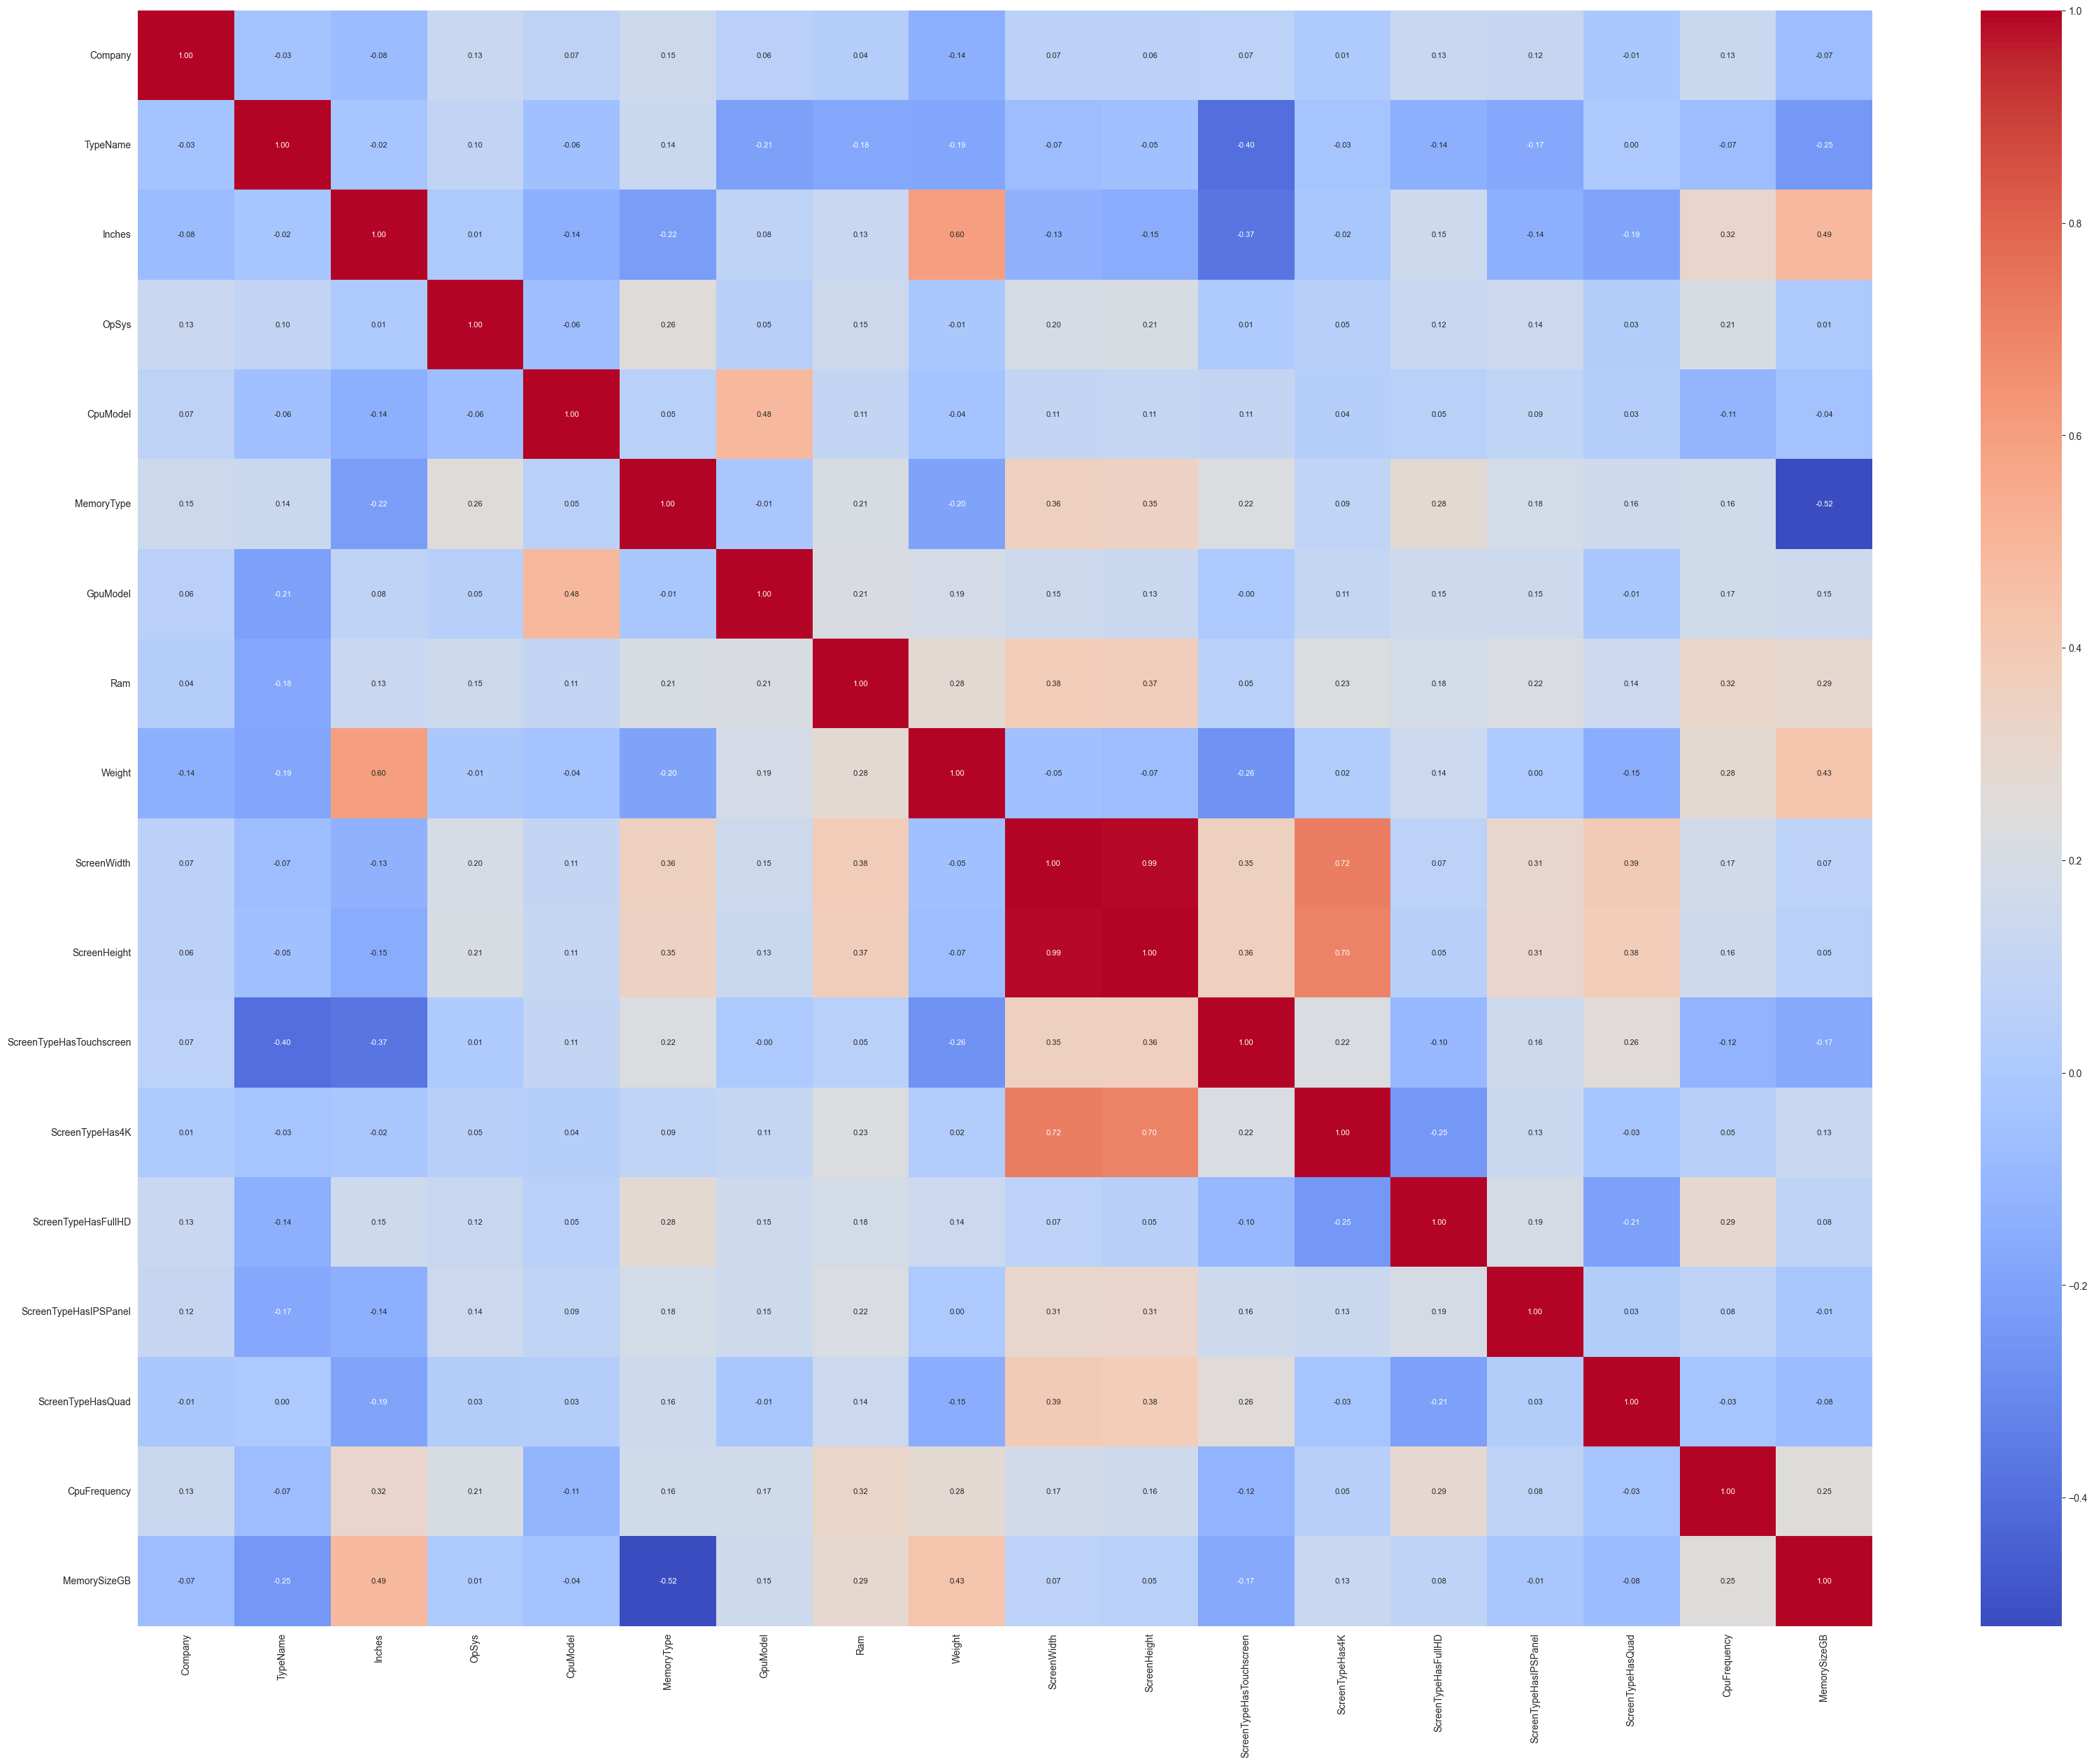

In [726]:
plt.figure(figsize=(40, 30))
sns.heatmap(
    X_train.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size":8},  # размер цифр
    xticklabels=X_train.columns,
    yticklabels=X_train.columns
)
plt.xticks(rotation=90)  # повернуть подписи по X
plt.yticks(rotation=0)   # по Y оставить горизонтально
plt.show()


# Обучение модели

Обучаем модель

In [727]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Создаем базовую модель DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)

param_grid_small = {
    'max_depth': [3, 5, 7, 10, 15, 20, 30, 40, 50, 100],
    'min_samples_leaf': [1, 5, 10, 15],
    'criterion': ['squared_error', 'absolute_error']
}

# GridSearch с кросс-валидацией
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_small,  # используем меньшую сетку для скорости
    cv=5,                          # 5-кратная кросс-валидация
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

print("🔍 Поиск лучших параметров для DecisionTreeRegressor...")
dt_grid.fit(X_train, y_train)

# Результаты
print(f"\n✅ Лучшие параметры: {dt_grid.best_params_}")

🔍 Поиск лучших параметров для DecisionTreeRegressor...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=1; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=1; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=1; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=1; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=1; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=5; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=5; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=5; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=10; total time=   0.0s
[CV] END criterion=squared_error, max_depth=3, min_samples_leaf=10; total time=   0.0s
[CV] END criterion=sq

In [728]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Сетка параметров
param_grid = {
    'n_estimators': [100, 300, 500, 800, 1000, 1250, 1500, 1750, 200],  # количество деревьев
    'max_depth': [5, 10, 15, 20, 25, 30, 50, 75, 100]         # максимальная глубина
}

# GridSearch с кросс-валидацией
rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                          # 5-кратная кросс-валидация
    scoring='neg_mean_squared_error',  # метрика для регрессии
    n_jobs=-1,
    verbose=2
)

print("Поиск лучших параметров...")
rf.fit(X_train, y_train)

# Результаты
print(f"\nЛучшие параметры: {rf.best_params_}")

Поиск лучших параметров...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.2s
[CV] END ......................max_depth=5, n_estimators=300; total time=   0.3s
[CV] END ......................max_depth=5, n_estimators=300; total time=   0.3s
[CV] END ......................max_depth=5, n_estimators=300; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=300; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=300; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=500; total time=   0.5s
[CV] END ...........

# Тестирование модели

## Обзор метрик

### MAE

**MAE (Mean Absolute Error)** — средняя абсолютная ошибка между истинными значениями и предсказаниями модели.

Формула MAE:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

Где:

- $n$ — количество наблюдений  
- $y_i$ — истинное значение целевой переменной  
- $\hat{y}_i$ — предсказанное моделью значение  
- $\left| y_i - \hat{y}_i \right|$ — абсолютная ошибка для $i$-го объекта  

MAE показывает, на сколько в среднем модель ошибается, и измеряется в тех же единицах, что и целевая переменная.

### MSE

**MSE (Mean Squared Error)** — средняя квадратичная ошибка между истинными значениями и предсказаниями модели.

Формула MSE:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$

Где:

- $n$ — количество наблюдений  
- $y_i$ — истинное значение целевой переменной  
- $\hat{y}_i$ — предсказанное моделью значение  
- $\left( y_i - \hat{y}_i \right)^2$ — квадрат ошибки для $i$-го объекта  

MSE сильнее штрафует большие ошибки, так как ошибка возводится в квадрат.

### R2

**R² (Coefficient of Determination)** — коэффициент детерминации, показывает долю объяснённой моделью дисперсии.

Формула R²:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

Где:

- $y_i$ — истинное значение  
- $\hat{y}_i$ — предсказанное значение  
- $\bar{y}$ — среднее значение целевой переменной  
- числитель — сумма квадратов ошибок модели  
- знаменатель — полная сумма квадратов (дисперсия данных)  

$R^2$ принимает значения от $-\infty$ до 1:  
- $R^2 = 1$ — идеальная модель  
- $R^2 = 0$ — модель не лучше среднего среднего значения
- $R^2 < 0$ — модель хуже константного предсказания

Получаем метрики

In [732]:
def print_metrics(y_pred, y_test):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print("=" * 50)
    print("📊 МЕТРИКИ МОДЕЛИ")
    print("=" * 50)
    print(f"MAE:  {mae:,.2f} руб")
    print(f"MSE:  {mse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print("=" * 50)

Метрики для обычного дерева-регрессора

In [734]:
y_dt_pred = dt_grid.predict(X_test)
print_metrics(y_dt_pred, y_test)

📊 МЕТРИКИ МОДЕЛИ
MAE:  12,515.58 руб
MSE:  329,775,357.67
R²:   0.7459
MAPE: 22.19%


In [735]:
y_rf_pred = rf.predict(X_test)
print_metrics(y_rf_pred, y_test)

📊 МЕТРИКИ МОДЕЛИ
MAE:  9,434.45 руб
MSE:  195,275,731.42
R²:   0.8495
MAPE: 17.21%


# График выходных результатов

In [736]:
def show_graphic(y_test, y_pred):
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Train: Actual vs Predicted")
    plt.show()

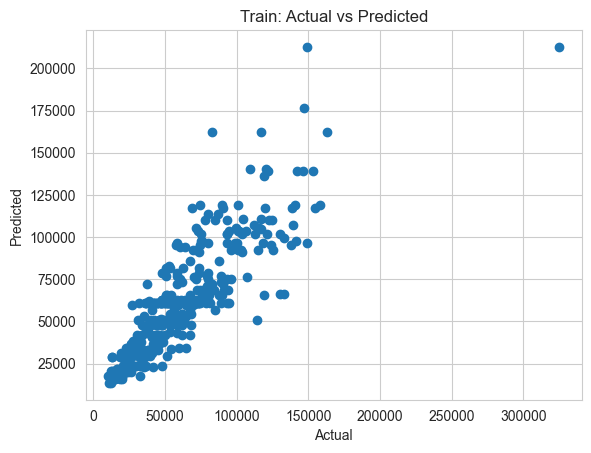

In [737]:
show_graphic(y_test, y_dt_pred)

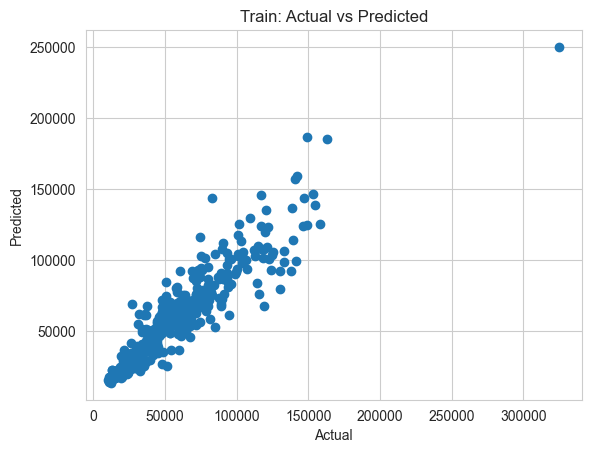

In [739]:
show_graphic(y_test, y_rf_pred)

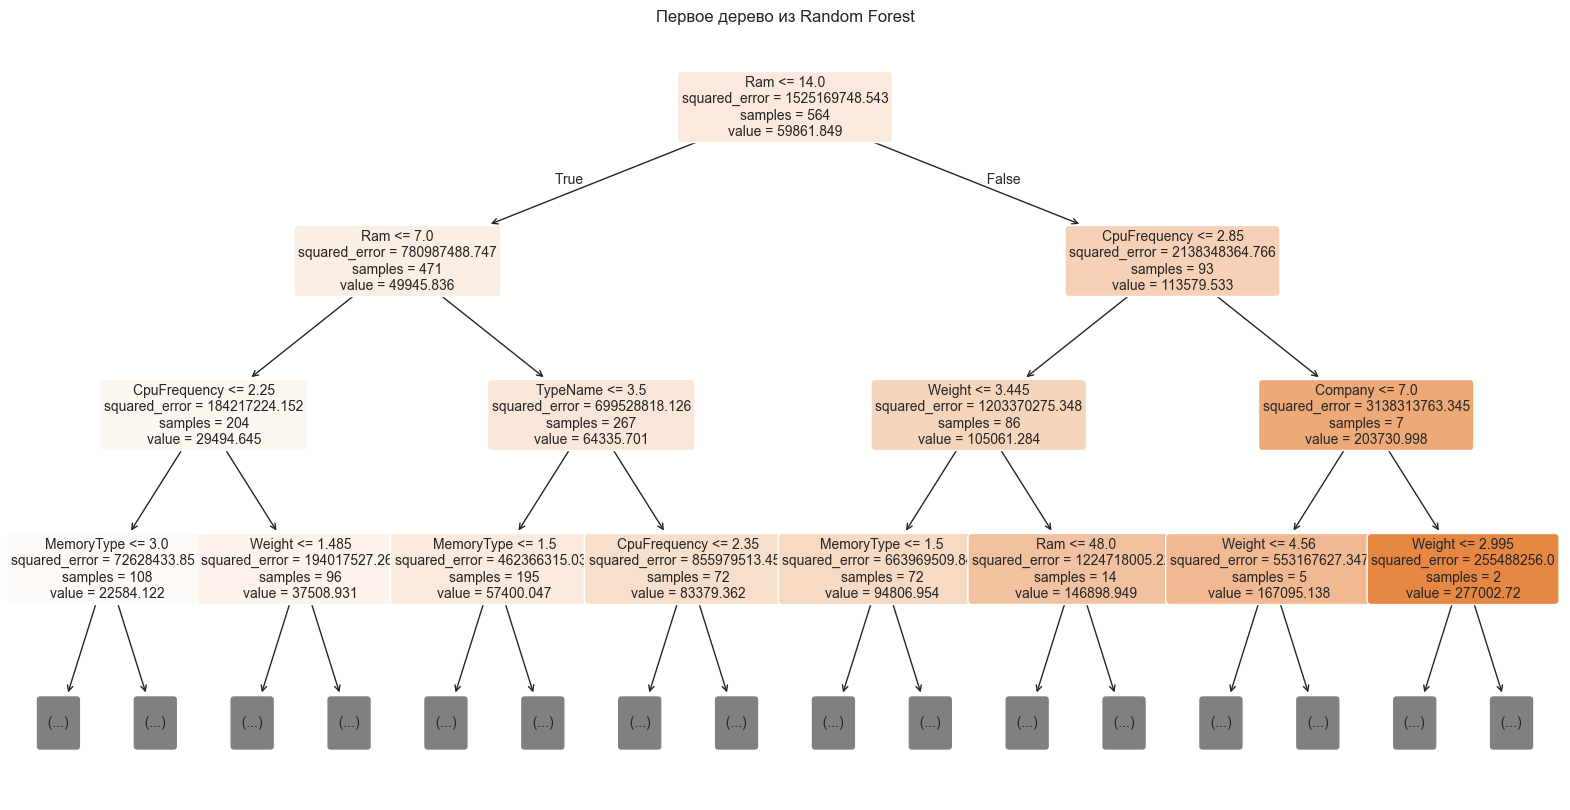

In [679]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    rf.best_estimator_.estimators_[0],  # первое дерево
    feature_names=X_train.columns.tolist(),  # названия признаков
    filled=True,  # закрашивать узлы
    rounded=True,  # скругленные углы
    fontsize=10,
    max_depth=3  # ограничить глубину для читаемости
)
plt.title("Первое дерево из Random Forest")
plt.show()